In [82]:
from ToyMaker import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

In [83]:
df = pd.read_csv('Tactic_model.csv')
# print(df.columns)
p = [df['p'][df['cell'] == c].to_list() for c in range(1, 1000+1)]
# print(p)
z = df['z'].to_list()
r = df['r'].to_list()
t = df['t'][df['cell'] == 1].to_list()

In [84]:
# Parameters

gamma_r = 1/5
gamma_p = 1/20
gamma_z = 1/20

kz = 3.2 * gamma_p
kr = 1
kp = 50

def γr(r): return gamma_r * r
def γp(p) : return gamma_p * p
def γz(z) : return gamma_z * z

def k_z() : return 3.2 * gamma_p
def k_r(z) : return kr * z * (gamma_z/kz)
def k_p(r) : return kp * r

In [88]:
%%time
species = {
            't':    0., 
            'cell': 0,
            'z': 0.,
            'r': 0.,
            'p': 0.,            
            }

reactions = {
            k_z: {'create':    ['z']},
            k_r: {'create':    ['r']},
            k_p: {'create':    ['p']},
            γz : {'destroy':   ['z']},
            γr : {'destroy':   ['r']},
            γp : {'destroy':   ['p']},
}


tmax = 300
sampling_time = 1
samples = 100

cells_4 = [Cell(species, reactions, tmax, sampling_time, cell=c, deterministic=False) for c in tqdm(range(1, 100+1))]
# cells = multiple_Cells(species, reactions, tmax, sampling_time, cells=samples);

100%|██████████| 100/100 [07:39<00:00,  4.59s/it]

CPU times: user 7min 30s, sys: 1.98 s, total: 7min 32s
Wall time: 7min 39s


In [ ]:
cells_to_save = np.array(cells_4)
np.save('constitutivo_raro_2.npy', cells_to_save)

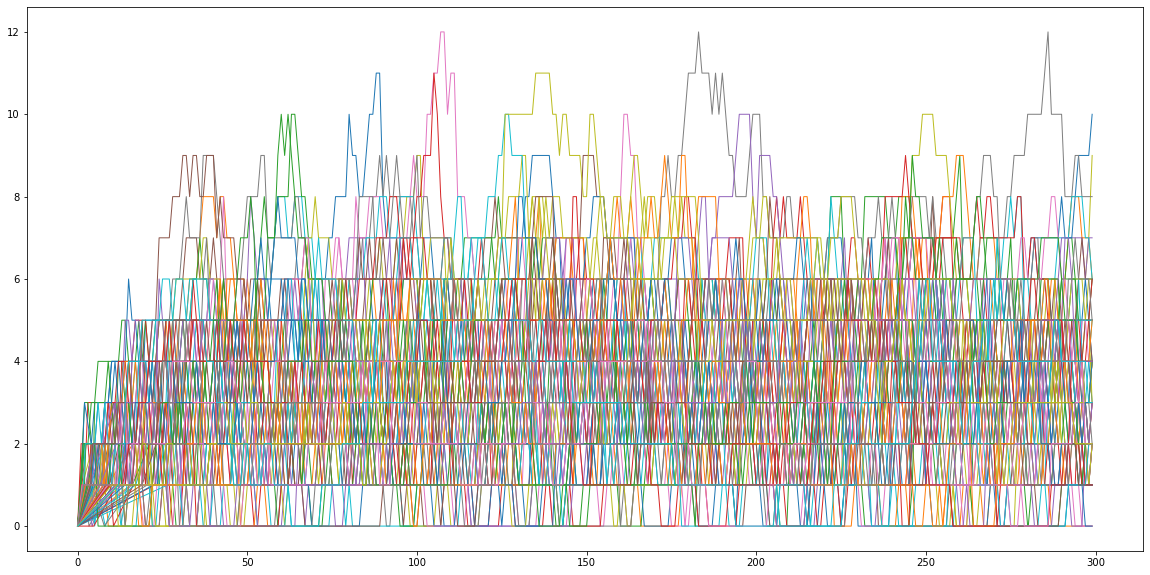

In [90]:
fig, ax = plt.subplots(figsize=(20,10))
[plt.plot(cells_4[c][:, 0], cells_4[c][:, 2], lw=1) for c in range(100)];

In [ ]:
def get_mean_per_cell(cells=[], samples=100, tmax=100, species_idx=2, single_value=False):
    
    if single_value == False:
        return np.array([np.mean([cells[sample][time:time + 1, species_idx] for sample in range(samples)]) for time in range(tmax)])
    
    elif single_value == True:
        mean = np.array([np.mean([cells[sample][time:time + 1, species_idx] for sample in range(samples)]) for time in range(tmax)])
        return mean[-100:].mean()


def get_variance_per_cell(cells=[], samples=100, tmax=100, species_idx=2, single_value=False):
    
    if single_value == False:
        return np.array([np.var([cells[sample][time:time + 1, species_idx] for sample in range(samples)]) for time in range(tmax)])

    elif single_value == True:
        var = np.array([np.var([cells[sample][time:time + 1, species_idx] for sample in range(samples)]) for time in range(tmax)])
        return var[-100:].mean()

In [ ]:
cells_to_save = cells

In [ ]:
mean = get_mean_per_cell(cells=cells, samples=samples, tmax=tmax, species_idx=4)
var = get_variance_per_cell(cells=cells, samples=samples, tmax=tmax, species_idx=4)
noise = calculate_noise(mean, var)

mean_sc = get_mean_per_cell(cells=cells, samples=samples, tmax=tmax, species_idx=4, single_value=True)
var_sc = get_variance_per_cell(cells=cells, samples=samples, tmax=tmax, species_idx=4, single_value=True)
noise_sc = calculate_noise(mean_sc, var_sc)
print(f'Mean: {mean_sc}')
print(f'Variance: {var_sc}')
print(f'Noise: {noise_sc}')

Mean: 4719.35668
Variance: 4268579.256384561
Noise: 0.1916539374498511


In [ ]:
mean = get_mean_per_cell(cells=cells, samples=samples, tmax=tmax, species_idx=2)
var = get_variance_per_cell(cells=cells, samples=samples, tmax=tmax, species_idx=2)
noise = calculate_noise(mean, var)

mean_sc = get_mean_per_cell(cells=cells, samples=samples, tmax=tmax, species_idx=2, single_value=True)
var_sc = get_variance_per_cell(cells=cells, samples=samples, tmax=tmax, species_idx=2, single_value=True)
noise_sc = calculate_noise(mean_sc, var_sc)
print(f'Mean: {mean_sc}')
print(f'Variance: {var_sc}')
print(f'Noise: {noise_sc}')

Mean: 2.9595000000000002
Variance: 2.904095579999999
Noise: 0.3315692273124243


In [ ]:
mean = get_mean_per_cell(cells=cells, samples=samples, tmax=tmax, species_idx=3)
var = get_variance_per_cell(cells=cells, samples=samples, tmax=tmax, species_idx=3)
noise = calculate_noise(mean, var)

mean_sc = get_mean_per_cell(cells=cells, samples=samples, tmax=tmax, species_idx=3, single_value=True)
var_sc = get_variance_per_cell(cells=cells, samples=samples, tmax=tmax, species_idx=3, single_value=True)
noise_sc = calculate_noise(mean_sc, var_sc)
print(f'Mean: {mean_sc}')
print(f'Variance: {var_sc}')
print(f'Noise: {noise_sc}')

Mean: 4.67835
Variance: 10.156979850000003
Noise: 0.46406538152596466
